#   Importación de librerías.

In [129]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

#   Matrices homogéneas.

Esta función genera una matriz homogénea utilizando los parámetros Denavit-Hartenberg.

-   theta -> rotación sobre Z.
-   alpha -> rotación sobre X.
-   a     -> longitud del eslabón.
-   d     -> desplazamiento.

Al final la función retorna directamente la matriz homogénea 4x4. Esta matriz permite transformar coordenadas entre sistemas de referencia.

Las primeras tres columnas representan orientación y la última columna representa posición.

Cada matriz representa:

-   Rotaciones
-   Traslaciones
-   Orientación
-   Posición

de una articulación respecto a otra.

In [130]:
def matriz_dh(theta, alpha, a, d):

    return np.array([

        # Primera fila de la matriz
        [
            np.cos(theta),                         # cos(theta)
            -np.sin(theta) * np.cos(alpha),       # -sin(theta)*cos(alpha)
            np.sin(theta) * np.sin(alpha),        # sin(theta)*sin(alpha)
            a * np.cos(theta)                     # desplazamiento en X
        ],

        # Segunda fila de la matriz
        [
            np.sin(theta),                        # sin(theta)
            np.cos(theta) * np.cos(alpha),       # cos(theta)*cos(alpha)
            -np.cos(theta) * np.sin(alpha),      # -cos(theta)*sin(alpha)
            a * np.sin(theta)                    # desplazamiento en Y
        ],

        # Tercera fila de la matriz
        [
            0,                                   # valor fijo
            np.sin(alpha),                       # sin(alpha)
            np.cos(alpha),                       # cos(alpha)
            d                                    # desplazamiento en Z
        ],

        # Cuarta fila para coordenadas homogéneas
        [
            0,
            0,
            0,
            1
        ]
    ])


#   Función de cinemática directa.

Esta función calcula la posición final del robot utilizando las variables articulares (q1, q2, q3, q4, q5).

La función retorna el vector posición y la matriz total.

In [ ]:
def cinematica_directa(variables_articulares):

    # Se desempaquetan las variables articulares
    q1, q2, q3, q4, q5 = variables_articulares

    # ======================================================
    # MATRICES D-H DE CADA ESLABÓN
    # ======================================================

    # Transformación del primer eslabón
    matriz_T1 = matriz_dh(q1, -np.pi/2, 0.5, 0)

    # Transformación del segundo eslabón
    matriz_T2 = matriz_dh(q2, np.pi/2, 0.4, 0)

    # Transformación del tercer eslabón (prismático)
    matriz_T3 = matriz_dh(0, 0, 0, q3)

    # Transformación del cuarto eslabón
    matriz_T4 = matriz_dh(q4, -np.pi/2, 0, 0)

    # Transformación del quinto eslabón
    matriz_T5 = matriz_dh(q5, np.pi/2, 0.3, 0)

    # Multiplicación de matrices

    # Aquí se obtiene la transformación total del robot
    matriz_total = (
        matriz_T1 @
        matriz_T2 @
        matriz_T3 @
        matriz_T4 @
        matriz_T5
    )

    # Extracción de posición final

    # Coordenada X del efector final
    posicion_x = matriz_total[0, 3]

    # Coordenada Y del efector final
    posicion_y = matriz_total[1, 3]

    # Coordenada Z del efector final
    posicion_z = matriz_total[2, 3]

    # Se retorna el vector posición y la matriz total
    return np.array([posicion_x, posicion_y, posicion_z]), matriz_total

#   Fitness.

Evalúa qué tan buena es una solución. 

Mientras más cerca esté el robot del objetivo mayor será el fitness.

La lógica de la fórmula es:

-   Si el error disminuye → el fitness aumenta
-   Si el error es cero → el fitness vale 1

Entonces el algoritmo intenta maximizar el fitness.

In [132]:
def funcion_fitness(variables_articulares, punto_objetivo):

    # Se obtiene la posición actual del efector final
    posicion_actual, _ = cinematica_directa(variables_articulares)

    # Error euclidiano
    # Distancia entre el punto objetivo y la posición actual
    error = np.linalg.norm(punto_objetivo - posicion_actual)

    # Fórmula del fitness
    # Si el error disminuye, el fitness aumenta
    fitness = 1 / (1 + error)

    # Se retorna fitness y error
    return fitness, error

#   Párametros del problema

-   Punto objetivo -> Meta a la que el robot debe llegar.
-   Límites articulares -> Restringen el movimiento de cada articulación..

In [133]:
# Punto objetivo al que el robot debe llegar
PUNTO_OBJETIVO = np.array([0.4, 0.3, 0.7])

LIMITES = np.array([

    # Límites de q1
    [-np.pi, np.pi],

    # Límites de q2
    [-np.pi, np.pi],

    # Límites de q3 (articulación prismática)
    [0.1, 1.0],

    # Límites de q4
    [-np.pi, np.pi],

    # Límites de q5
    [-np.pi, np.pi]
])

#   Párametros del PSO.

In [134]:
# Número total de partículas
NUMERO_PARTICULAS = 50

# Número máximo de iteraciones
MAX_ITERACIONES = 200

# Número de dimensiones del problema
DIMENSIONES = 5

# Factor de inercia
# Valor alto -> + exploración
# Valor bajo -> + explotación
w = 0.7 # Controla cuanto conserva la partícula de su movimiento anterior

# Componente cognitiva
c1 = 1.5 # que recuerda su mejor experiencia personal

# Componente social
c2 = 1.5 # siga al mejor individuo global

#   Inicialización de partículas.

In [135]:
# Matriz para almacenar las partículas
particulas = np.zeros((NUMERO_PARTICULAS, DIMENSIONES))

# Matriz para almacenar velocidades
velocidades = np.zeros((NUMERO_PARTICULAS, DIMENSIONES)) # cada partícula tiene velocidad

#   Generar partículas random.

In [136]:
for indice_dimension in range(DIMENSIONES):

    # Generar valores aleatorios dentro de los límites
    particulas[:, indice_dimension] = np.random.uniform(

        # Límite inferior
        LIMITES[indice_dimension, 0],

        # Límite superior
        LIMITES[indice_dimension, 1],

        # Cantidad de partículas
        NUMERO_PARTICULAS
    )

#   Mejores posiciones personales.

In [137]:
# Copia inicial de partículas
mejores_posiciones_personales = np.copy(particulas)

# Vector para guardar fitness personal
mejor_fitness_personal = np.zeros(NUMERO_PARTICULAS)

#   Evaluación incial del fitness.

In [138]:
# Recorrer cada partícula
for indice_particula in range(NUMERO_PARTICULAS):

    # Evaluar fitness de la partícula
    fitness_actual, _ = funcion_fitness(
        particulas[indice_particula],
        PUNTO_OBJETIVO
    )

    # Guardar fitness
    mejor_fitness_personal[indice_particula] = fitness_actual

#   Mejor solución global.

In [139]:
# Índice de la mejor partícula
indice_mejor_global = np.argmax(mejor_fitness_personal)

# Mejor posición global encontrada
mejor_posicion_global = (
    mejores_posiciones_personales[indice_mejor_global].copy()
)

# Mejor fitness global
mejor_fitness_global = mejor_fitness_personal[indice_mejor_global]

#   PSO.

El algoritmo PSO lo usé porque la cinemática inversa puede volverse complicada de resolver de forma analítica, especialmente cuando existen múltiples grados de libertad o restricciones articulares. Entonces, en lugar de resolver ecuaciones complejas manualmente, el PSO busca una solución óptima mediante inteligencia colectiva inspirada en el comportamiento de enjambres.

In [140]:
# Lista donde se guardará el fitness por iteración
curva_convergencia = []

# Recorrer iteraciones
for iteracion in range(MAX_ITERACIONES):

    # Recorrer partículas
    for indice_particula in range(NUMERO_PARTICULAS):

        # Números aleatorios
        # Vector aleatorio cognitivo
        r1 = np.random.rand(DIMENSIONES)

        # Vector aleatorio social
        r2 = np.random.rand(DIMENSIONES)

        # Actualización de velocidad
        velocidades[indice_particula] = (

            # Parte de inercia
            w * velocidades[indice_particula]

            # Parte cognitiva
            + c1 * r1 * (
                mejores_posiciones_personales[indice_particula]
                - particulas[indice_particula]
            )

            # Parte social
            + c2 * r2 * (
                mejor_posicion_global
                - particulas[indice_particula]
            )
        )

        # Actualización de posición.
        # La nueva posición se obtiene sumando velocidad
        particulas[indice_particula] += (
            velocidades[indice_particula]
        )

        # Respetar límites articulares
        # Recorrer dimensiones
        for indice_dimension in range(DIMENSIONES):

            # Limitar valores usando clip
            particulas[indice_particula, indice_dimension] = np.clip(

                # Valor actual
                particulas[indice_particula, indice_dimension],

                # Límite mínimo
                LIMITES[indice_dimension, 0],

                # Límite máximo
                LIMITES[indice_dimension, 1]
            )

        # Fitness actual
        fitness_actual, error_actual = funcion_fitness(
            particulas[indice_particula],
            PUNTO_OBJETIVO
        )

        # Actualizar mejor personal
        # Si el fitness actual es mejor
        if fitness_actual > mejor_fitness_personal[indice_particula]:

            # Actualizar fitness personal
            mejor_fitness_personal[indice_particula] = fitness_actual

            # Guardar nueva mejor posición
            mejores_posiciones_personales[indice_particula] = (
                particulas[indice_particula].copy()
            )

        # Actualizar mejor global
        # Si se encontró una mejor solución
        if fitness_actual > mejor_fitness_global:

            # Actualizar mejor fitness global
            mejor_fitness_global = fitness_actual

            # Actualizar mejor posición global
            mejor_posicion_global = (
                particulas[indice_particula].copy()
            )

    # Guardar fitness de la iteración
    curva_convergencia.append(mejor_fitness_global)

    # Mostrar avance del algoritmo
    print(
        f"Iteración {iteracion+1}/{MAX_ITERACIONES}"
        f" | Fitness = {mejor_fitness_global:.6f}"
    )

Iteración 1/200 | Fitness = 0.802348
Iteración 2/200 | Fitness = 0.817961
Iteración 3/200 | Fitness = 0.884794
Iteración 4/200 | Fitness = 0.914328
Iteración 5/200 | Fitness = 0.921362
Iteración 6/200 | Fitness = 0.927205
Iteración 7/200 | Fitness = 0.927205
Iteración 8/200 | Fitness = 0.936082
Iteración 9/200 | Fitness = 0.951777
Iteración 10/200 | Fitness = 0.951898
Iteración 11/200 | Fitness = 0.951898
Iteración 12/200 | Fitness = 0.951898
Iteración 13/200 | Fitness = 0.953585
Iteración 14/200 | Fitness = 0.976127
Iteración 15/200 | Fitness = 0.976127
Iteración 16/200 | Fitness = 0.983449
Iteración 17/200 | Fitness = 0.983449
Iteración 18/200 | Fitness = 0.987088
Iteración 19/200 | Fitness = 0.987088
Iteración 20/200 | Fitness = 0.988236
Iteración 21/200 | Fitness = 0.990476
Iteración 22/200 | Fitness = 0.990476
Iteración 23/200 | Fitness = 0.990476
Iteración 24/200 | Fitness = 0.993218
Iteración 25/200 | Fitness = 0.993218
Iteración 26/200 | Fitness = 0.993218
Iteración 27/200 | Fi

#   Resultados finales.

In [141]:
# Obtener posición final del robot
mejor_posicion_robot, matriz_final = cinematica_directa(
    mejor_posicion_global
)

# Calcular error final
error_final = np.linalg.norm(
    PUNTO_OBJETIVO - mejor_posicion_robot
)

# Mostrar resultados
print("\n>>> RESULTADOS <<<")

print("Mejor solución encontrada:")
print(mejor_posicion_global)

print("\nPosición final alcanzada:")
print(mejor_posicion_robot)

print("\nPunto objetivo:")
print(PUNTO_OBJETIVO)

print(f"\nError final: {error_final:.6f}")

print(f"Fitness final: {mejor_fitness_global:.6f}")


>>> RESULTADOS <<<
Mejor solución encontrada:
[ 0.64350111 -0.24473731  0.87128888  3.14159265  0.69514125]

Posición final alcanzada:
[0.4 0.3 0.7]

Punto objetivo:
[0.4 0.3 0.7]

Error final: 0.000000
Fitness final: 1.000000


#   Gráficas.

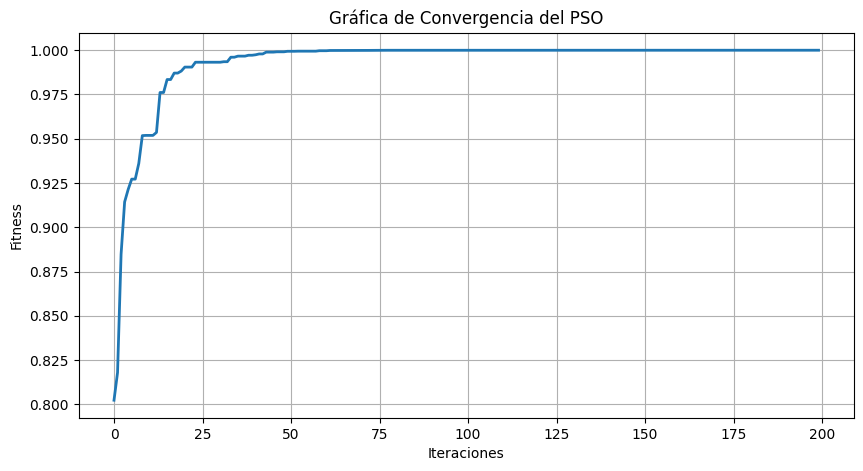

In [142]:
# Crear figura
plt.figure(figsize=(10, 5))

# Graficar curva de convergencia
plt.plot(curva_convergencia, linewidth=2)

# Etiqueta eje X
plt.xlabel('Iteraciones')

# Etiqueta eje Y
plt.ylabel('Fitness')

# Título de la gráfica
plt.title('Gráfica de Convergencia del PSO')

# Activar cuadrícula
plt.grid(True)

# Mostrar gráfica
plt.show()

#   Obtener puntos del robot.

Esta función obtiene las posiciones de cada articulación para poder dibujar el robot.

In [143]:
def obtener_puntos_robot(variables_articulares):
    # Desempaquetar variables articulares
    q1, q2, q3, q4, q5 = variables_articulares

    # Matriz identidad inicial
    matriz_T0 = np.identity(4)

    # Transformaciones acumuladas
    matriz_T1 = matriz_T0 @ matriz_dh(q1, -np.pi/2, 0.5, 0)

    matriz_T2 = matriz_T1 @ matriz_dh(q2, np.pi/2, 0.4, 0)

    matriz_T3 = matriz_T2 @ matriz_dh(0, 0, 0, q3)

    matriz_T4 = matriz_T3 @ matriz_dh(q4, -np.pi/2, 0, 0)

    matriz_T5 = matriz_T4 @ matriz_dh(q5, np.pi/2, 0.3, 0)

    # Arreglo de puntos del robot
    puntos_robot = np.array([

        # Base del robot
        [0, 0, 0],

        # Posición articulación 1
        matriz_T1[:3, 3],

        # Posición articulación 2
        matriz_T2[:3, 3],

        # Posición articulación 3
        matriz_T3[:3, 3],

        # Posición articulación 4
        matriz_T4[:3, 3],

        # Posición efector final
        matriz_T5[:3, 3]
    ])

    # Retornar puntos
    return puntos_robot

#   Gráfico 3D robot.

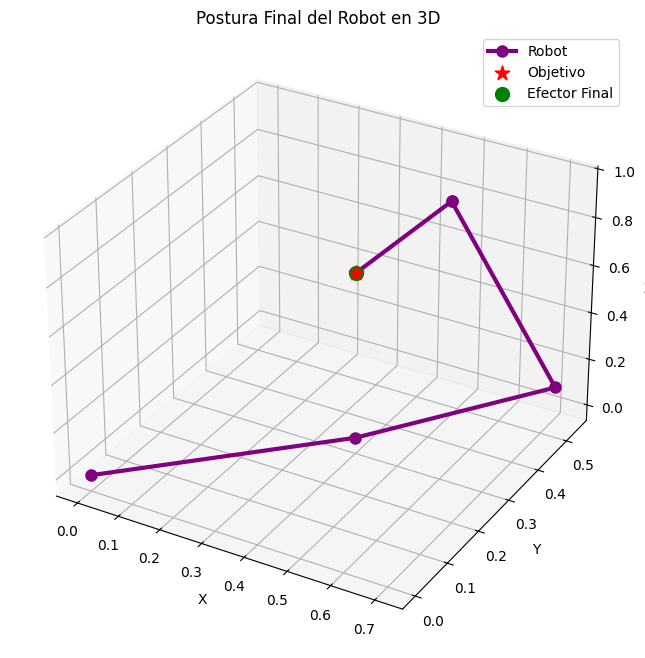

In [144]:
# Obtener puntos del robot
puntos_robot = obtener_puntos_robot(mejor_posicion_global)

# Crear figura
figura = plt.figure(figsize=(10, 8))

# Crear ejes 3D
ejes = figura.add_subplot(111, projection='3d')

ejes.plot(

    # Coordenadas X
    puntos_robot[:, 0],

    # Coordenadas Y
    puntos_robot[:, 1],

    # Coordenadas Z
    puntos_robot[:, 2],

    # Estilo de línea y marcador
    '-o',

    color='purple',

    # Grosor de línea
    linewidth=3,

    # Tamaño de marcador
    markersize=8,

    # Etiqueta
    label='Robot'
)

ejes.scatter(

    # Coordenada X
    PUNTO_OBJETIVO[0],

    # Coordenada Y
    PUNTO_OBJETIVO[1],

    # Coordenada Z
    PUNTO_OBJETIVO[2],

    # Tamaño
    s=120,

    # Tipo de marcador
    marker='*',

    color='red',

    # Etiqueta
    label='Objetivo'
)

ejes.scatter(

    # Coordenada X
    mejor_posicion_robot[0],

    # Coordenada Y
    mejor_posicion_robot[1],

    # Coordenada Z
    mejor_posicion_robot[2],

    # Tamaño
    s=100,

    color='green',

    # Etiqueta
    label='Efector Final'
)

# Etiqueta eje X
ejes.set_xlabel('X')

# Etiqueta eje Y
ejes.set_ylabel('Y')

# Etiqueta eje Z
ejes.set_zlabel('Z')

# Título
ejes.set_title('Postura Final del Robot en 3D')

# Mostrar leyenda
ejes.legend()

# Mostrar gráfica
plt.show()